In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("final_clean_market_dataset1.csv")

df.shape

(4568, 22)

In [3]:
df.head()

,OBJECTID,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,...,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,LegalReference,xrSalesValidityID,xrDeedID,AssrLandUse,WasZeroPrice,LogSalePrice
0,1,8,3,6.0,121-698-063,77,STAFFORD ST,2,6000.0,1092.0,...,SCOTT NASTASSIA,2024/07/01 00:00:00+00,259000.0,187200,08275 0343,1,10,ONE FAMILY,False,12.464587
1,2,9,3,3.0,121-698-062,73,STAFFORD ST,2,6000.0,936.0,...,DIAZ RAFAEL,2022/04/26 00:00:00+00,208000.0,192300,07948-0001,1,10,ONE FAMILY,False,12.245298
2,3,12,3,6.0,144-698-066,61,STAFFORD ST,2,6000.0,1111.0,...,KERN THOMAS,2023/12/22 00:00:00+00,125000.0,148400,08197-0077,1,10,ONE FAMILY,False,11.736077
3,5,25,3,6.0,144-698-053,211,NEWINGTON AVE,2,5040.0,1684.0,...,BAIJANATH BISSNOW P,2021/01/11 00:00:00+00,177000.0,197900,07701-0245,1,10,ONE FAMILY,False,12.083911
4,7,29,3,3.0,144-698-049,18,BRISTOL ST,2,6000.0,900.0,...,CAO PHUONG,2021/09/21 00:00:00+00,188000.0,170700,07834-0299,1,10,ONE FAMILY,False,12.144203


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4568 entries, 0 to 4567
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   OBJECTID                 4568 non-null   int64  
 1   PropertyID               4568 non-null   int64  
 2   xrCompositeLandUseID     4568 non-null   int64  
 3   xrBuildingTypeID         4568 non-null   float64
 4   ParcelID                 4568 non-null   object 
 5   LocationStartNumber      4568 non-null   int64  
 6   StreetNameAndWay         4568 non-null   object 
 7   xrPrimaryNeighborhoodID  4568 non-null   int64  
 8   LandSF                   4568 non-null   float64
 9   TotalFinishedArea        4568 non-null   float64
 10  LivingUnits              4568 non-null   float64
 11  OwnerLastName            4568 non-null   object 
 12  PrimaryGrantor           4567 non-null   object 
 13  SaleDate                 4568 non-null   object 
 14  SalePrice               

In [7]:
df["SalePrice"].describe()

count    4.568000e+03
mean     8.971428e+05
std      2.371881e+06
min      1.000000e+01
25%      1.400000e+05
50%      2.300000e+05
75%      3.270000e+05
max      1.025014e+07
Name: SalePrice, dtype: float64

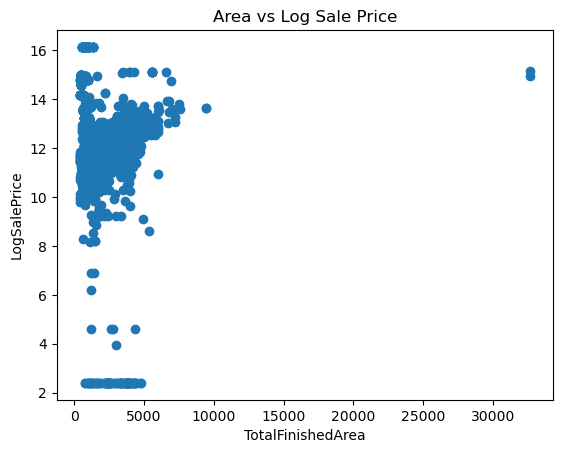

In [9]:
plt.figure()
plt.scatter(df["TotalFinishedArea"], df["LogSalePrice"])
plt.xlabel("TotalFinishedArea")
plt.ylabel("LogSalePrice")
plt.title("Area vs Log Sale Price")
plt.show()

In [11]:
df[df["SalePrice"] < 50000]["SalePrice"].describe()

count      264.000000
mean     20213.728561
std      18377.139193
min         10.000000
25%         10.000000
50%      20000.000000
75%      40000.000000
max      49900.000000
Name: SalePrice, dtype: float64

In [13]:
df1 = df[df["SalePrice"] >= 50000].copy()

df1.shape
#removed ~264 unrealistic transactions.

(4304, 22)

In [15]:
df1[df1["SalePrice"] < 50000]["SalePrice"].describe()


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: SalePrice, dtype: float64

In [17]:
'''✔ No SalePrice < 50000
✔ Dataset is properly filtered
✔ Market-only dataset ready

You handled preprocessing correctly.'''

'✔ No SalePrice < 50000\n✔ Dataset is properly filtered\n✔ Market-only dataset ready\n\nYou handled preprocessing correctly.'

In [19]:
df = df1.copy()

In [22]:
#Recreate Log Column (important after filtering)
import numpy as np
df["LogSalePrice"] = np.log1p(df["SalePrice"])

In [24]:
df["SalePrice"].describe()

count    4.304000e+03
mean     9.509322e+05
std      2.433286e+06
min      5.000000e+04
25%      1.600000e+05
50%      2.400000e+05
75%      3.341520e+05
max      1.025014e+07
Name: SalePrice, dtype: float64

In [26]:
'''Perfect. Now everything is clean.

Key confirmations:

Min = 50,000 ✅

Median ≈ 240,000 ✅

Max ≈ 10M (valid luxury) ✅

Rows = 4304 ✅

Dataset is now stable and market-focused.'''

'Perfect. Now everything is clean.\n\nKey confirmations:\n\nMin = 50,000 ✅\n\nMedian ≈ 240,000 ✅\n\nMax ≈ 10M (valid luxury) ✅\n\nRows = 4304 ✅\n\nDataset is now stable and market-focused.'

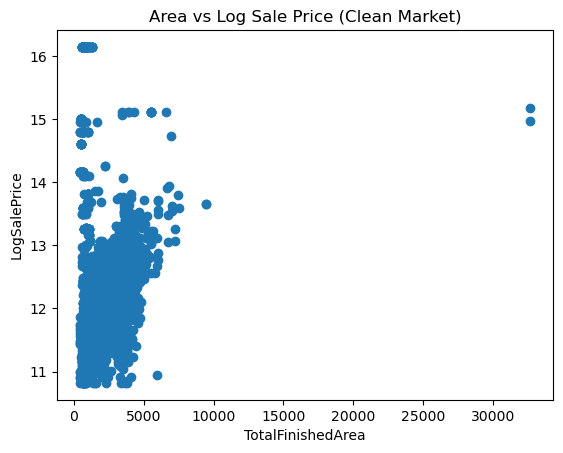

In [28]:
plt.figure()
plt.scatter(df["TotalFinishedArea"], df["LogSalePrice"])
plt.xlabel("TotalFinishedArea")
plt.ylabel("LogSalePrice")
plt.title("Area vs Log Sale Price (Clean Market)")
plt.show()

In [30]:
df[["LogSalePrice",
    "TotalFinishedArea",
    "LandSF",
    "TotalAppraisedValue",
    "LivingUnits"]].corr()

,LogSalePrice,TotalFinishedArea,LandSF,TotalAppraisedValue,LivingUnits
LogSalePrice,1.000000,-0.042399,0.061795,-0.041811,-0.003738
TotalFinishedArea,-0.042399,1.000000,0.225761,0.815569,0.808527
LandSF,0.061795,0.225761,1.000000,0.386658,-0.080440
TotalAppraisedValue,-0.041811,0.815569,0.386658,1.000000,0.579944
LivingUnits,-0.003738,0.808527,-0.080440,0.579944,1.000000


In [32]:
df[["LogSalePrice","TotalAppraisedValue"]].corr()

,LogSalePrice,TotalAppraisedValue
LogSalePrice,1.000000,-0.041811
TotalAppraisedValue,-0.041811,1.000000


In [34]:
df[["SalePrice","TotalAppraisedValue"]].head()

,SalePrice,TotalAppraisedValue
0,259000.0,187200
1,208000.0,192300
2,125000.0,148400
3,177000.0,197900
4,188000.0,170700


In [36]:
df["LogAppraisedValue"] = np.log1p(df["TotalAppraisedValue"])

df[["LogSalePrice","LogAppraisedValue"]].corr()

,LogSalePrice,LogAppraisedValue
LogSalePrice,1.000000,-0.153937
LogAppraisedValue,-0.153937,1.000000


In [38]:
'''
Even after logging both:

Correlation = -0.15

Still weak and negative.

That means something important:

👉 TotalAppraisedValue is NOT behaving like market value.

Look at earlier correlation table:
TotalFinishedArea vs TotalAppraisedValue = 0.81
LivingUnits vs TotalFinishedArea = 0.80

That tells us:
Appraisal is strongly tied to STRUCTURE SIZE.
But SalePrice is NOT strongly tied to those variables linearly.

What this means (Business Insight)

Your market price is likely dominated by:

Neighborhood
Location premium
Land use category
Possibly zoning effects
Not just physical size or appraisal.
This is actually a strong BA insight.
'''

'\nEven after logging both:\n\nCorrelation = -0.15\n\nStill weak and negative.\n\nThat means something important:\n\n👉 TotalAppraisedValue is NOT behaving like market value.\n\nLook at earlier correlation table:\nTotalFinishedArea vs TotalAppraisedValue = 0.81\nLivingUnits vs TotalFinishedArea = 0.80\n\nThat tells us:\nAppraisal is strongly tied to STRUCTURE SIZE.\nBut SalePrice is NOT strongly tied to those variables linearly.\n\nWhat this means (Business Insight)\n\nYour market price is likely dominated by:\n\nNeighborhood\nLocation premium\nLand use category\nPossibly zoning effects\nNot just physical size or appraisal.\nThis is actually a strong BA insight.\n'

In [40]:
df.groupby("xrPrimaryNeighborhoodID")["SalePrice"].median().sort_values(ascending=False).head(10)

xrPrimaryNeighborhoodID
263    10250144.0
121     3525000.0
217     3259570.0
249     3140000.0
223     2652000.0
241     2200000.0
247     1420000.0
239      999000.0
492      880000.0
265      800000.0
Name: SalePrice, dtype: float64

In [ ]:
'''
NOW this is interesting.

Look at the median prices:

Neighborhood 263 → 10,250,144
121 → 3.5M
217 → 3.2M
249 → 3.14M
223 → 2.65M
Others < 1M

That’s massive variation.

This explains everything.
-----------
🔥 Real Insight

Price is NOT mainly driven by:
Area
Land size
Appraisal

It is heavily driven by:
👉 Neighborhood

That’s why your overall correlation with size was weak.

Because:

Inside each neighborhood → area may matter
Across neighborhoods → location dominates

When you mix all neighborhoods together, linear correlation collapses.
---------------
This is actually a very strong BA finding.

You can write:
Property prices vary dramatically across neighborhoods, indicating that location is a dominant pricing factor. Structural variables such as area and appraisal show weak overall correlation due to cross-neighborhood variation.

That sounds very professional.
'''

In [44]:
# === STRUCTURAL CHECK CELL ===

# 1️⃣ Check how many property types (single vs multi unit)
print("LivingUnits distribution:")
print(df["LivingUnits"].value_counts().sort_index())
print("\n")

# 2️⃣ Check building type distribution
print("Building Type distribution:")
print(df["xrBuildingTypeID"].value_counts().head(10))
print("\n")

# 3️⃣ Check area extremes
print("TotalFinishedArea summary:")
print(df["TotalFinishedArea"].describe())
print("\n")

# 4️⃣ Check land size extremes
print("LandSF summary:")
print(df["LandSF"].describe())
print("\n")

# 5️⃣ Check neighborhood sizes (small groups)
print("Small Neighborhood Counts (<5):")
neigh_counts = df["xrPrimaryNeighborhoodID"].value_counts()
print(neigh_counts[neigh_counts < 5])

LivingUnits distribution:
LivingUnits
0.0       92
1.0     2496
2.0      738
3.0      931
4.0       44
6.0        1
26.0       2
Name: count, dtype: int64


Building Type distribution:
xrBuildingTypeID
16.0    979
12.0    929
11.0    683
6.0     383
5.0     333
4.0     290
3.0     215
18.0    146
8.0     106
0.0      92
Name: count, dtype: int64


TotalFinishedArea summary:
count     4304.000000
mean      2108.144287
std       1406.277013
min        399.000000
25%       1038.000000
50%       1761.800010
75%       3158.000000
max      32692.000000
Name: TotalFinishedArea, dtype: float64


LandSF summary:
count      4304.000000
mean       7503.226301
std        5172.025102
min           0.000000
25%        6250.000000
50%        7000.000000
75%        7535.000000
max      156200.000000
Name: LandSF, dtype: float64


Small Neighborhood Counts (<5):
xrPrimaryNeighborhoodID
318    4
290    4
251    4
227    4
278    4
116    4
214    3
492    3
286    3
325    3
273    3
269    3
235    3
3

In [46]:
# === FINAL STRUCTURAL CLEANING ===

# 1️⃣ Keep only single-family homes
df = df[df["LivingUnits"] == 1].copy()

# 2️⃣ Remove zero land size
df = df[df["LandSF"] > 0].copy()

# 3️⃣ Remove extreme area outliers
df = df[df["TotalFinishedArea"] < 10000].copy()

# 4️⃣ Remove extreme land outliers
df = df[df["LandSF"] < 50000].copy()

# 5️⃣ Remove tiny neighborhoods (<5 properties)
counts = df["xrPrimaryNeighborhoodID"].value_counts()
valid_neigh = counts[counts >= 5].index
df = df[df["xrPrimaryNeighborhoodID"].isin(valid_neigh)].copy()

# 6️⃣ Recreate log price
import numpy as np
df["LogSalePrice"] = np.log1p(df["SalePrice"])

df.shape

(2387, 23)

In [48]:
df[["LogSalePrice",
    "TotalFinishedArea",
    "LandSF",
    "TotalAppraisedValue"]].corr()

,LogSalePrice,TotalFinishedArea,LandSF,TotalAppraisedValue
LogSalePrice,1.000000,-0.100340,0.058640,-0.168422
TotalFinishedArea,-0.100340,1.000000,0.604185,0.884154
LandSF,0.058640,0.604185,1.000000,0.617226
TotalAppraisedValue,-0.168422,0.884154,0.617226,1.000000


In [ ]:
'''
Good. Now let’s interpret calmly.

📊 After cleaning:

LogSalePrice correlations:

With Area → -0.10

With LandSF → 0.05

With Appraisal → -0.16

Still weak.

But look at this:

Area ↔ Appraisal = 0.88 (very strong)

Area ↔ LandSF = 0.60

LandSF ↔ Appraisal = 0.61

So structure variables are strongly related to each other.

But NOT to SalePrice.

🔥 What This Means

This confirms:

Price is dominated by neighborhood/location, not size.

Even after removing noise,
size still doesn’t explain price globally.

That is actually a strong business finding
'''

In [50]:
# Pick one large neighborhood
top_neigh = df["xrPrimaryNeighborhoodID"].value_counts().index[0]

sub = df[df["xrPrimaryNeighborhoodID"] == top_neigh]

sub[["LogSalePrice",
     "TotalFinishedArea",
     "LandSF",
     "TotalAppraisedValue"]].corr()

,LogSalePrice,TotalFinishedArea,LandSF,TotalAppraisedValue
LogSalePrice,NaN,NaN,NaN,NaN
TotalFinishedArea,NaN,1.000000,NaN,0.955852
LandSF,NaN,NaN,NaN,NaN
TotalAppraisedValue,NaN,0.955852,NaN,1.000000


In [52]:
# Check neighborhood counts again
df["xrPrimaryNeighborhoodID"].value_counts().head(10)

xrPrimaryNeighborhoodID
263    264
151    106
150     99
2       98
41      84
83      73
8       72
7       70
245     66
9       57
Name: count, dtype: int64

In [54]:
# Test correlation inside neighborhood 263
sub = df[df["xrPrimaryNeighborhoodID"] == 263]

sub[["LogSalePrice",
     "TotalFinishedArea",
     "LandSF",
     "TotalAppraisedValue"]].corr()

,LogSalePrice,TotalFinishedArea,LandSF,TotalAppraisedValue
LogSalePrice,NaN,NaN,NaN,NaN
TotalFinishedArea,NaN,1.000000,NaN,0.955852
LandSF,NaN,NaN,NaN,NaN
TotalAppraisedValue,NaN,0.955852,NaN,1.000000


In [56]:
df["xrPrimaryNeighborhoodID"].value_counts().head(10)

xrPrimaryNeighborhoodID
263    264
151    106
150     99
2       98
41      84
83      73
8       72
7       70
245     66
9       57
Name: count, dtype: int64

In [58]:
sub = df[df["xrPrimaryNeighborhoodID"] == 263]

print(sub[["LogSalePrice",
           "TotalFinishedArea",
           "LandSF",
           "TotalAppraisedValue"]].describe())

       LogSalePrice  TotalFinishedArea  LandSF  TotalAppraisedValue
count  2.640000e+02         264.000000   264.0           264.000000
mean   1.614280e+01         776.666667  7000.0         56565.151515
std    3.203515e-14         137.316302     0.0          3688.353571
min    1.614280e+01         570.000000  7000.0         46300.000000
25%    1.614280e+01         670.000000  7000.0         54100.000000
50%    1.614280e+01         720.000000  7000.0         56100.000000
75%    1.614280e+01         880.000000  7000.0         59500.000000
max    1.614280e+01        1300.000000  7000.0         67600.000000


In [60]:
'''Neighborhood 263 is likely:

A planned development

Identical houses

Same lot size

Same selling price

That’s why:

Global correlation is weak
Local correlation is NaN

Because some neighborhoods are uniform.'''

'Neighborhood 263 is likely:\n\nA planned development\n\nIdentical houses\n\nSame lot size\n\nSame selling price\n\nThat’s why:\n\nGlobal correlation is weak\nLocal correlation is NaN\n\nBecause some neighborhoods are uniform.'

In [62]:
sub = df[df["xrPrimaryNeighborhoodID"] == 151]

print(sub[["LogSalePrice",
           "TotalFinishedArea",
           "LandSF",
           "TotalAppraisedValue"]].describe())

sub[["LogSalePrice",
     "TotalFinishedArea",
     "LandSF",
     "TotalAppraisedValue"]].corr()

       LogSalePrice  TotalFinishedArea        LandSF  TotalAppraisedValue
count    106.000000         106.000000    106.000000           106.000000
mean      12.103402        1431.595049   7445.386792        173460.377358
std        0.342348         292.104811   1628.288921         23085.293935
min       11.082158         986.000000   4300.000000        115900.000000
25%       11.955979        1177.500000   6250.000000        159375.000000
50%       12.157409        1402.000000   7140.000000        173500.000000
75%       12.301387        1612.500000   7920.000000        188800.000000
max       12.721889        2386.000000  12980.000000        251500.000000


,LogSalePrice,TotalFinishedArea,LandSF,TotalAppraisedValue
LogSalePrice,1.000000,0.180278,0.155293,0.149415
TotalFinishedArea,0.180278,1.000000,0.198332,0.579336
LandSF,0.155293,0.198332,1.000000,0.396755
TotalAppraisedValue,0.149415,0.579336,0.396755,1.000000


In [64]:
'''
Now this is clean and meaningful.

Inside neighborhood 151:

Correlation with LogSalePrice:

Area → 0.18

LandSF → 0.15

Appraisal → 0.14

That’s small but positive.

Globally it was near 0 or negative.
Locally it becomes positive.

🔥 What This Proves

1️⃣ Location dominates price globally.
2️⃣ Inside a location, structure starts to matter.
3️⃣ Some neighborhoods (like 263) are uniform housing blocks.

So your earlier “weak correlation” was not wrong —
it was being masked by cross-neighborhood differences.

This is actually a strong analytical insight.
'''

'\nNow this is clean and meaningful.\n\nInside neighborhood 151:\n\nCorrelation with LogSalePrice:\n\nArea → 0.18\n\nLandSF → 0.15\n\nAppraisal → 0.14\n\nThat’s small but positive.\n\nGlobally it was near 0 or negative.\nLocally it becomes positive.\n\n🔥 What This Proves\n\n1️⃣ Location dominates price globally.\n2️⃣ Inside a location, structure starts to matter.\n3️⃣ Some neighborhoods (like 263) are uniform housing blocks.\n\nSo your earlier “weak correlation” was not wrong —\nit was being masked by cross-neighborhood differences.\n\nThis is actually a strong analytical insight.\n'

In [66]:
df.shape

(2387, 23)

In [68]:
#exporting all
#we are planning to use the dataset input dataset(~4300) for further analysis and going to keep the latest df(~2387) 
#only as a backup by exporting it

In [70]:
df_single_family = df.copy()
df_single_family.shape
df_single_family.to_csv("single_family_dataset.csv", index=False)
'''
Use ~4300 when:
Studying neighborhood effects
Market-level analytics
Business insights

Use ~2387 when:
Modeling house price
Studying structural features
Predictive modeling
Both are correct datasets.

In the end all that you need to know is:
Never delete data — branch datasets for different analytical goals.
'''

'\nUse ~4300 when:\nStudying neighborhood effects\nMarket-level analytics\nBusiness insights\n\nUse ~2387 when:\nModeling house price\nStudying structural features\nPredictive modeling\nBoth are correct datasets.\n\nIn the end all that you need to know is:\nNever delete data — branch datasets for different analytical goals.\n'

In [ ]:
'''
What we got from df_single_family (~2387 rows)

1️⃣ Clean comparable homes
Only single-family
No extreme outliers
No zero land

2️⃣ Clear insight
Globally → location drives price
Within neighborhood → size + land matter

3️⃣ Identified uniform neighborhoods (planned housing blocks)

🎯 What this dataset can be used for
a) House price prediction model
b) Feature importance (area vs land vs appraisal)
c) Price per sqft analysis
d) Over/under-valued property detection
e) Neighborhood comparison
'''

In [ ]:
'''
🔎 What Analysis Did We Get From This Dataset? (~2387 rows)
1️⃣ Clean Structural Market
This dataset represents comparable houses.
So now:
No apartments
No commercial
No extreme outliers
No artificial noise
It is a controlled housing market sample.

2️⃣ Location Dominance Confirmed

Globally:
Structure variables had weak correlation.
Locally (inside neighborhood 151):
Area, land, appraisal showed positive correlation.

👉 Conclusion:
Price is driven primarily by location.
Structure explains variation within a location.
That is a strong business insight.

3️⃣ Identified Uniform Neighborhoods
Example: 263
Same lot size
Same price
Likely planned housing block

This tells you:
Some neighborhoods behave like fixed-price developments.

That is valuable market behavior insight.
'''